# Preparing a nested simulation with CDR ii: Child simulation with CDR release

In the previous step of this tutorial, we ran a ROMS simulation of the northeast Atlantic for two months (January and February 2012), in order to generate boundary and initial data for a higher-resolution nested domain of the Denmark Strait near northwest Iceland, into which we will introduce a CDR intervention. Treating January as a model spin-up, we will now prepare and run this child simulation for the month of February 2012. 

The preparation differs from the previous step in the following ways:
- The model grid has already been prepared (in the previous step) and simply needs to be loaded into memory
- The initial conditions will not be made from scratch using reanalysis data, but will be generated from the parent simulation's restart file
- The boundary forcing will also come from the parent - the `iceland_parent_ext.*.nc` output files (generated in the previous run) will be converted into compatible boundary forcing files
- We will prepare a CDR forcing file describing the alkalinity perturbation we wish to make to the child simulation
- We need to configure the child simulation to record any CDR-related tracers leaving the domain, such that we can run the parent domain a second time to track their transport into the broader ocean. This second run will be the basis of the next and final page of this tutorial

Other preparation steps (rivers, surface forcing, and tides) remain the same as before. After preparing the above inputs, we will compile and run the simulation, before plotting CDR-related outputs.

## Requirements:
The requirements are the same as the previous tutorial page, with the addition that the previous step must have been successfully completed and its outputs available.

In [1]:
import os
os.chdir(f"{os.environ.get("ROMS_ROOT")}/Examples/Iceland/Iceland_child")

In [2]:
%matplotlib inline

In [3]:
from pathlib import Path

import xarray as xr
import datetime as dt
import roms_tools as rt
import matplotlib.pyplot as plt

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


After setting this cell according to your own source data paths, the rest of the notebook should run:

In [4]:
# ROMS tools source data:
rtd=Path("~/Code/roms_tools_datasets")

topo_path = rtd/"SRTM15_V2.5.nc" # Topography (SRTM15)
era5_path = [rtd/"ERA5_2012-01.nc", rtd/"ERA5_2012-02.nc"] # Surface forcing (ERA5)
bgc_path = rtd/"BGC/BGCdataset.nc" # BGC tracers for initial and boundary conditions (CWorthy unified BGC dataset)
bgc_surf_path = rtd/"BGC/BGCdataset.nc" # BGC surface forcing (CWorthy unified BGC dataset)
glorys_paths = [rtd/f"GLORYS/mercatorglorys12v1_gl12_mean_2012{m:02}{d:02}.nc" for m in range(1,3) for d in range(1,32)][:-2] # Interior state for initial and boundary conditions (GLORYS)
tpxo_path = rtd/"TPXO10.v2/" # Tidal forcing (TPXO)

## Simulation domain
We saved the grid in the previous tutorial, so we can import it here:

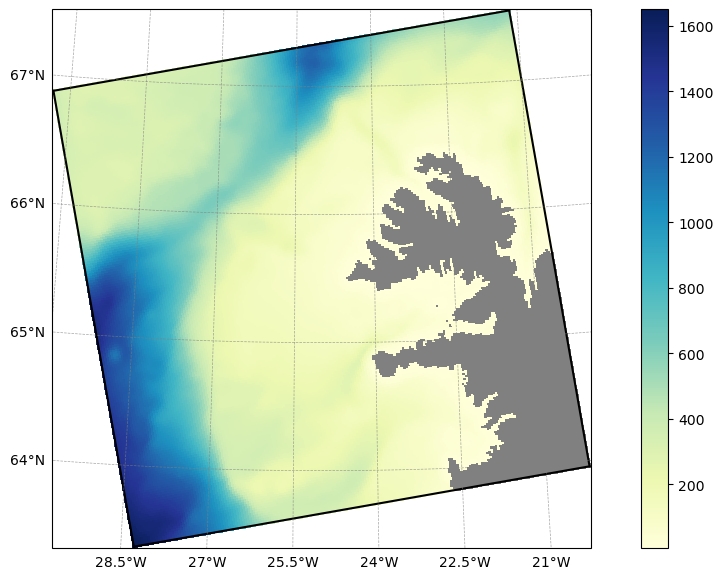

In [5]:
child_grid = rt.Grid.from_file("input_data/iceland_child_grid.nc")
child_grid.plot()

The grid-related parameters are set in `roms.in`, as described on the previous page of the tutorial.

## Simulation timing
We will run the simulation for the month of February, using the restart and boundary data generated by the parent after its first month.

In [6]:
forcing_start_time = dt.datetime(2012,2,1,0,0,0)
forcing_end_time = dt.datetime(2012,3,1,0,0,0)
ini_time = dt.datetime(2012,2,1,0,0,0)

We will run this simulation for 28 days, starting on the 1st of February at midnight. As the resolution is much higher we must use a smaller time-step. By setting the time-step to 300 seconds, we require 28*86400/300 = 8064 time-steps. We thus set `dt` to `300` and `NTIMES` to `8064` in `roms.in`

## Pre-processing boundary and initial condition data from the parent simulation
### Boundary forcing
During the parent simulation, we used the nesting information generated with `roms-tools` to output `_ext` files, which we can now process into boundary forcing files for the child domain. The tool for this is `extract_data_join`, included with `roms`:

In [ ]:
%%bash
cd input_data
# We want to loop over the filename stems, so we'll use the `.0.nc` files as a template
for F in $ROMS_ROOT/Examples/Iceland/Iceland_parent/output/iceland_parent_ext.??????????????.0.nc;do

    # Get filename stem, e.g. 
    # output/iceland_parent_ext.20120101120000.0.nc -> output/iceland_parent_ext.20120101120000
    filename_stem=${F/.0.nc}  

    # wildcard to join all subdomains with this stem
    extract_data_join ${filename_stem}.?.nc
done

_(Cell output hidden due to length)_

This generates boundary data with the name `child_bry.??????????????.nc`:

In [8]:
ls input_data

child_bry.20120101130000.nc  ocean.20120101130000.nc
child_bry.20120103130000.nc  ocean.20120103130000.nc
child_bry.20120105130000.nc  ocean.20120105130000.nc
child_bry.20120107130000.nc  ocean.20120107130000.nc
child_bry.20120109130000.nc  ocean.20120109130000.nc
child_bry.20120111130000.nc  ocean.20120111130000.nc
child_bry.20120113130000.nc  ocean.20120113130000.nc
child_bry.20120115130000.nc  ocean.20120115130000.nc
child_bry.20120117130000.nc  ocean.20120117130000.nc
child_bry.20120119130000.nc  ocean.20120119130000.nc
child_bry.20120121130000.nc  ocean.20120121130000.nc
child_bry.20120123130000.nc  ocean.20120123130000.nc
child_bry.20120125130000.nc  ocean.20120125130000.nc
child_bry.20120127130000.nc  ocean.20120127130000.nc
child_bry.20120129130000.nc  ocean.20120129130000.nc
child_bry.20120131130000.nc  ocean.20120131130000.nc
child_bry.20120202130000.nc  ocean.20120202130000.nc
child_bry.20120204130000.nc  ocean.20120204130000.nc
child_bry.20120206130000.nc  ocean.20120206130

The `ocean.*` files here can be ignored. To avoid copying each name into the `roms.in` forcing file list, we can concatenate the boundary forcing files into a single file using `ncrcat`:

In [9]:
%%bash
ncrcat input_data/child_bry.??????????????.nc  -o input_data/iceland_child_boundary_forcing.nc
rm input_data/ocean.??????????????.nc
rm input_data/child_bry.??????????????.nc
ls input_data

iceland_child_boundary_forcing.nc
iceland_child_grid.nc


### Initial conditions
`roms-tools` allows us to create the initial conditions for the child simulation using a restart file and grid file from the parent simulation.

In [10]:
restart_file=f"../Iceland_parent/output/iceland_parent_rst.20120201000000.nc"
parent_grid = rt.Grid.from_file("../Iceland_parent/input_data/iceland_parent_grid.nc")

initial_conditions_from_parent = rt.InitialConditions(
    grid=child_grid,
    ini_time=dt.datetime(2012,2,1,0,0,0),
    source={"name": "ROMS", "grid": parent_grid, "path": restart_file},
    use_dask=True,
    bgc_source={
        "name": "ROMS",
        "grid": parent_grid,
        "path": restart_file,
    },
)
child_initial_conditions_path = initial_conditions_from_parent.save("input_data/iceland_child_initial_conditions.nc")

2026-03-18 14:02:31 - INFO - Writing the following NetCDF files:
input_data/iceland_child_initial_conditions.nc


[########################################] | 100% Completed | 1.47 sms


More information on this process can be found in the [`roms-tools` documentation](https://roms-tools.readthedocs.io/en/latest/initial_conditions.html#Initializing-from-ROMS-Restart-Files).

## Creating other input data
We make the remaining input data using `roms-tools` as we did on the previous page of the tutorial:
### Surface forcing

In [11]:
child_surface_forcing = rt.SurfaceForcing(
    grid = child_grid,
    start_time = forcing_start_time,
    end_time= forcing_end_time,
    type= "physics",
    source={"name": "ERA5", "path": era5_path},
    use_dask=True,
)

child_surface_forcing_path = child_surface_forcing.save("input_data/iceland_child_surface_forcing.nc",group=False)

2026-03-18 14:02:33 - WARNING - No records found after the end_time: 2012-03-01 00:00:00.
2026-03-18 14:02:33 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.
2026-03-18 14:02:46 - INFO - Writing the following NetCDF files:
input_data/iceland_child_surface_forcing.nc


[########################################] | 100% Completed | 32.76 s


### BGC Surface Forcing

In [12]:
child_bgc_surface_forcing = rt.SurfaceForcing(
    grid=child_grid,
    start_time=forcing_start_time,
    end_time=forcing_end_time,
    source={"name": "UNIFIED", "path": bgc_surf_path, "climatology": True},
    type="bgc",
    use_dask=True,
)
child_bgc_surface_forcing_path = child_bgc_surface_forcing.save("input_data/iceland_child_bgc_surface_forcing.nc",group=False)

2026-03-18 14:03:22 - WARNING - Optional variables missing (but not critical): ['pco2_air_alt']
2026-03-18 14:03:22 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.
2026-03-18 14:03:22 - INFO - Writing the following NetCDF files:
input_data/iceland_child_bgc_surface_forcing.nc


[########################################] | 100% Completed | 106.31 ms


### River Forcing

2026-03-18 14:03:23 - INFO - No river indices provided. Identify all rivers within the ROMS domain and assign each of them to the nearest coastal point.
2026-03-18 14:03:24 - INFO - Compute climatology for river forcing.
2026-03-18 14:03:24 - INFO - Creating 1 synthetic river(s) to handle overlapping entries.


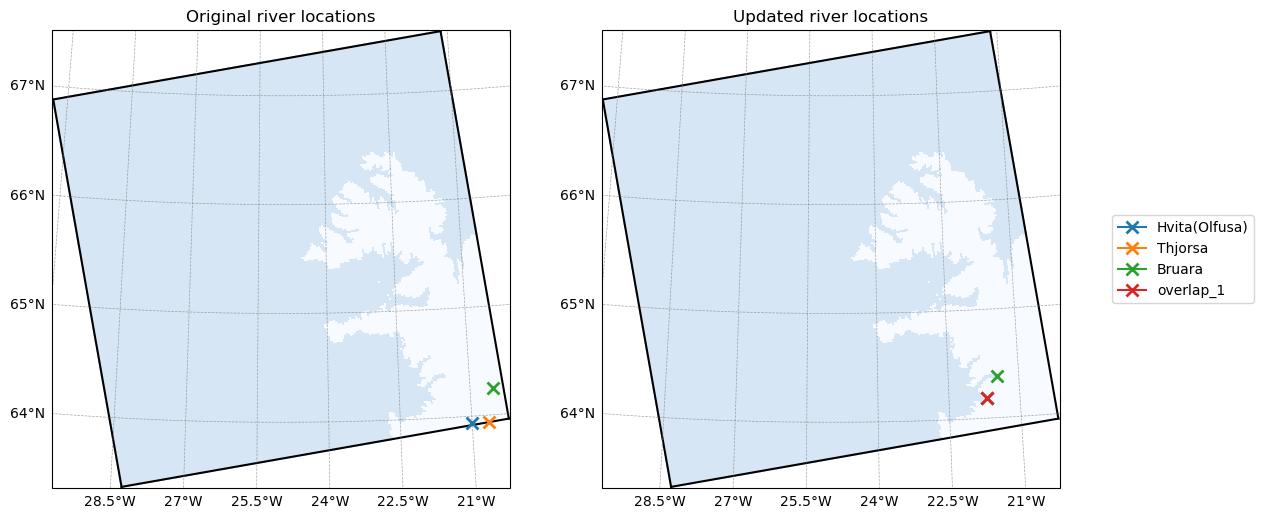

In [13]:
child_river_forcing = rt.RiverForcing(
    grid=child_grid,
    start_time=forcing_start_time,
    end_time=forcing_end_time,
    model_reference_date=dt.datetime(2000, 1, 1), # this is the default
    include_bgc=True
)
child_river_forcing.plot_locations()

In [14]:
child_river_forcing_path = child_river_forcing.save("input_data/iceland_child_river_forcing.nc")

2026-03-18 14:03:24 - INFO - Writing the following NetCDF files:
input_data/iceland_child_river_forcing.nc


## Tidal Forcing

[########################################] | 100% Completed | 105.99 ms


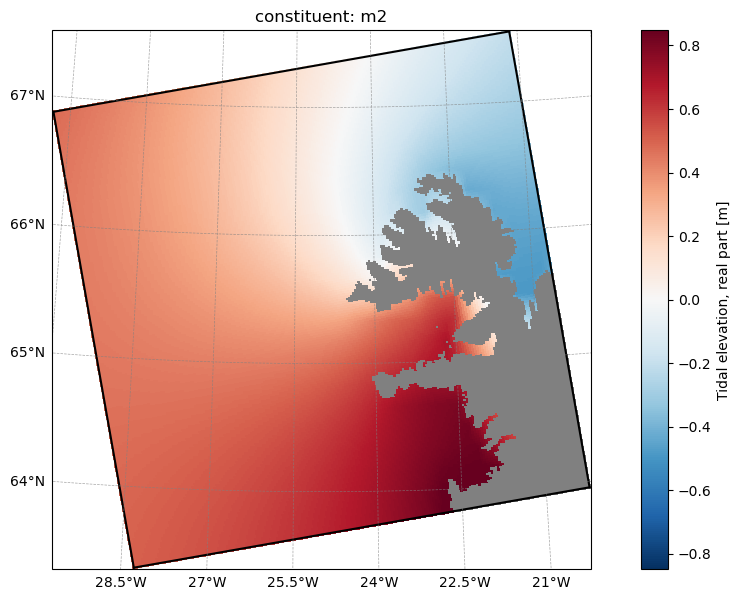

In [15]:
tpxo_dict = {
    "grid": tpxo_path / "grid_tpxo10v2.nc",
    "h": tpxo_path / "h_tpxo10.v2.nc",
    "u": tpxo_path / "u_tpxo10.v2.nc",
}

child_tidal_forcing = rt.TidalForcing(
    grid=child_grid,
    source={"name": "TPXO", "path": tpxo_dict},
    use_dask=True
)
child_tidal_forcing.plot("ssh_Re", ntides=0)

In [16]:
child_tidal_forcing_path = child_tidal_forcing.save("input_data/iceland_child_tides.nc")

2026-03-18 14:03:26 - INFO - Writing the following NetCDF files:
input_data/iceland_child_tides.nc


[########################################] | 100% Completed | 740.61 ms


## CDR Forcing
We now prepare an Ocean Alkalinity Enhancement perturbation using `roms-tools`. `roms-tools` allows us to add a time-varying flux to a tracer (here alkalinity) with a Gaussian spatial distribution in the horizontal and vertical, specified by the parameters `hsc` and `vsc`:

In [17]:
constant_oae_iceland = rt.TracerPerturbation(
    name="iceland_oae",
    lat=67.0,  # degree N
    lon=-25,  # degree E
    depth=100,  # m
    hsc=100000,  # Gaussian horizontal scale, m
    vsc=50,  # Gaussian vertical scale, m
    tracer_fluxes={"ALK": 2 * 10**6},  # meq/s
)
child_cdr_forcing = rt.CDRForcing(
    grid=child_grid,
    start_time=forcing_start_time,
    end_time=forcing_end_time,
    releases=[
        constant_oae_iceland,
    ],
)

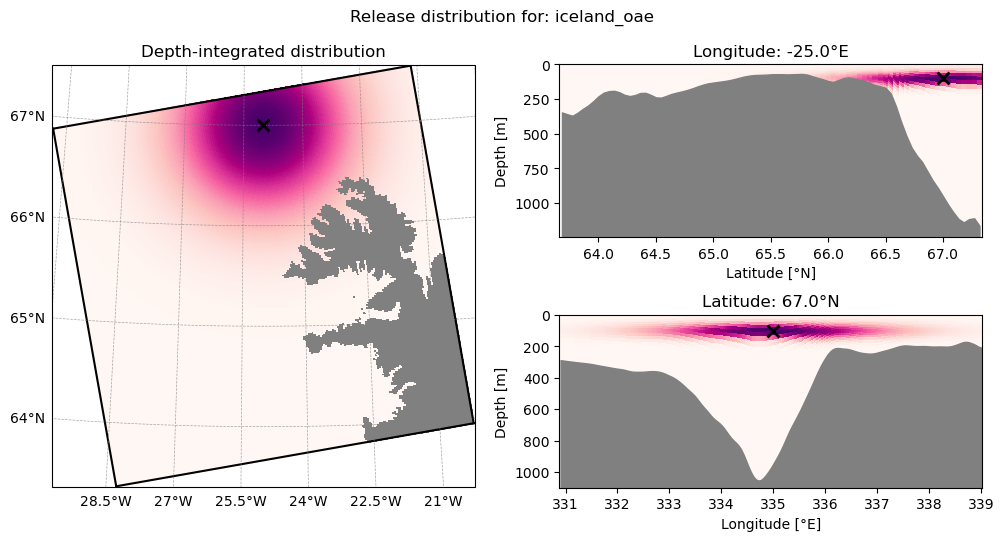

In [18]:
child_cdr_forcing.plot_distribution(release_name="iceland_oae")

In [19]:
child_cdr_forcing.save("input_data/iceland_child_cdr_forcing.nc")

2026-03-18 14:03:28 - INFO - Writing the following NetCDF files:
input_data/iceland_child_cdr_forcing.nc


[PosixPath('input_data/iceland_child_cdr_forcing.nc')]

Again, more information can be found on the corresponding `roms-tools` [documentation page](https://roms-tools.readthedocs.io/en/latest/cdr_forcing.html).

To configure ROMS to use this flux perturbation, we must edit the `cdr_frc.opt` file:


| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `cdr_frc.opt` | `cdr_source` | Tells ROMS we will be applying CDR forcing | `.true.` |
|               | `cdr_file` | Path to the netCDF file we created above | `input_data/iceland_child_cdr_forcing.nc` |
|               | `forcing_parameterized`* | Tells ROMS that we are providing forcing as a parameterized spatial distribution | `.true.` |
|               | `forcing_3d`* | Tells ROMS that we are providing forcing with a fully specified (non-parameterized) 3D spatial distribution | `.false.` |
|               | `forcing_depth_profiles`* | Tells ROMS that we are providing forcing as a sequence of 2D depth profiles | `.false.` |
|               | `ncdr_parm`| Number of parameterized releases | `1` |
|               | `time_interpolation`| Tells ROMS to interpolate linearly between consecutive records, rather than holding it constant until the next record | `.false.` |
|               | `relocate_to_wet_pts`| Tells ROMS to relocate any release locations on land to the nearest wet point | `.false.` |
|               | `cdr_volume`| Tells ROMS that the CDR release will be a [volume flux](https://roms-tools.readthedocs.io/en/latest/cdr_forcing.html#Creating-a-Release), rather than a tracer flux | `.false.` |
|               | `nz_chd`| The number of layers in the forcing file, which may differ from the target domain (as we shall see in the next tutorial) | `0` (unused) |


\* Note: only one of these three options can be `.true.` at once.

These are all the settings we need for this simulation, others, concerning other types of release and more advanced options are documented with comments in `cdr_frc.opt`.

Note the `cdr_file` variable: we specify the forcing file here, rather than in `roms.in` with the other forcing files. CDR forcing files are unique in that they are not defined on the model grid and do not require additional pre-processing such as partitioning.

## Configuring upscaling
As we are injecting an alkalinity perturbation into the child simulation, the anomalous tracer will eventually reach the boundaries of the domain. In order to continue to study its transport, we can use ROMS' upscaling functionality, which will record and output tracer fluxes at the boundary to be used as forcing in a second run of the parent simulation. This is controlled in the `upscale_output.opt` file:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `upscale_output.opt` | `do_upscale` | Tells ROMS to record boundary alkalinity fluxes | `.true.` |
|                      | `output_period_uscl` | Frequency to create outputs for upscaling (seconds) | `3600` (hourly) |
|                      | `nrpf_uscl` | The number of records in each output file before beginning a new one | `24` (one file per day) |

With these settings, the model will produce an additional set of outputs, `iceland_child_uscl.??????????????.*.nc`, one file per model day, with an entry every model hour. These can be converted into CDR forcing for the next run of the parent simulation, as we will see on the next page of this tutorial.


## Configuring CDR-relevant model output

In addition to the output settings configured on the previous page of the tutorial, we can ask ROMS for specifically CDR-relevant output via the `cdr_output` module. The settings are similar to the other output option files:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
|`cdr_output.opt`| `do_cdr` | Tells ROMS whether to write mCDR-specific outputs | `.true.` |
|                  | `do_avg` | Tells ROMS whether to write instantaneous or time-averaged outputs | `.true.` |
|                  | `output_period` | requency of file creation / averaging period (if `.do_avg.`)(s) | `86400` (daily) |
|                  | `monthly_averages` | If `true`, ignores above frequency and averages over each _calendar_ month | `.false.` |
|                  | `nprf` | Number of records in each output file before beginning a new file | `28` |

## Pre-processing
As on the previous page of the tutorial, we need to partition the files we have prepared here for parallel execution (with the exception of the CDR forcing file, as mentioned above)

In [ ]:
%%bash
cd input_data/
partit 3 3 iceland_child_grid.nc
partit 3 3 iceland_child_initial_conditions.nc
partit 3 3 iceland_child_surface_forcing.nc
partit 3 3 iceland_child_bgc_surface_forcing.nc
partit 3 3 iceland_child_boundary_forcing.nc
partit 3 3 iceland_child_river_forcing.nc
partit 3 3 iceland_child_tides.nc


_(Cell output hidden due to length)_

## Compile and run

In [ ]:
%%bash
make compile_clean
make

_(Cell output hidden due to length)_

In [ ]:
%%bash
mpirun -n 9 ./roms roms.in

_(Cell output hidden due to length)_

## Post-processing
As with the parent simulation, all the outputs are written to subdomain tiles that need to be joined with `ncjoin`:

In [ ]:
%%bash
cd output
# We want to loop over the filename stems, so we'll use the `.0.nc` files as a template
for F in *.0.nc;do

    # Get filename stem, e.g. 
    # output/iceland_parent_uscl.20120201000000.0.nc -> output/iceland_parent_uscl.20120201000000
    filename_stem=${F/.0.nc}  

    # Skip any `_ext` files, to be addressed separately:
    if [[ "${filename_stem}" == *"_ext."* ]]; then
        continue
    fi

    # wildcard to join all subdomains with this stem
    ncjoin ${filename_stem}.?.nc
done

_(Cell output truncated due to length)_

## Outputs and CDR evaluation
Recall that we set up the outputs a little differently in this simulation, including the `upscale_output` and `cstar_output` modules. Here are the files the model produced:

These output files collect all variables and diagnostics we consider relevant to CDR experiments. Of note is that each of the biogeochemical variables has a secondary entry with the suffix `_ALT_CO2`. This is because MARBL, the biogeochemical library we are using, simulates two carbonate chemistry systems in parallel, allowing modelers to explore an alternative forcing scenario (hence `_ALT_CO2`) without having to re-run the full ocean circulation model. As we only perturbed the alkalinity in one of those two carbonate systems, we can use this feature to examine the difference in carbon with and without the intervention, without running the model a second time.

You can expand the attributes of each variable to see its description and units, but here we will take a quick look at the impact of our alkalinity perturbation using the following variables:

- `hALK`: alkalinity multiplied by local layer thickness. Summing this over the vertical column gives the local depth-integrated alkalinity
- `hALK_ALT_CO2`: as above, but in the alternative carbonate chemistry system. We did not perturb the secondary carbonate chemistry, so can use it  as a baseline to visualize the propagation of our intervention
- `hDIC`: dissolved inorganic carbon multiplied by local layer thickness. Summing this over the vertical column gives the local depth-integrated DIC
- `hDIC_ALT_CO2`:  as above, but in the alternative carbonate chemistry system. We did not perturb the secondary carbonate chemistry, so can use it  as a baseline to visualize the propagation of our intervention

Let's take a look at the propagation of our alkalinity perturbation and the response in ocean carbon during the second month of our simulation:

/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_62130/3487358885.py:6: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data_ds=xr.open_dataset("output/iceland_child_cstar.20120202000000.nc")
/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_62130/3487358885.py:32: UserWarning: Adding colorbar to a different Figure <Figure size 1500x1000 with 28 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  cb=fig2.colo

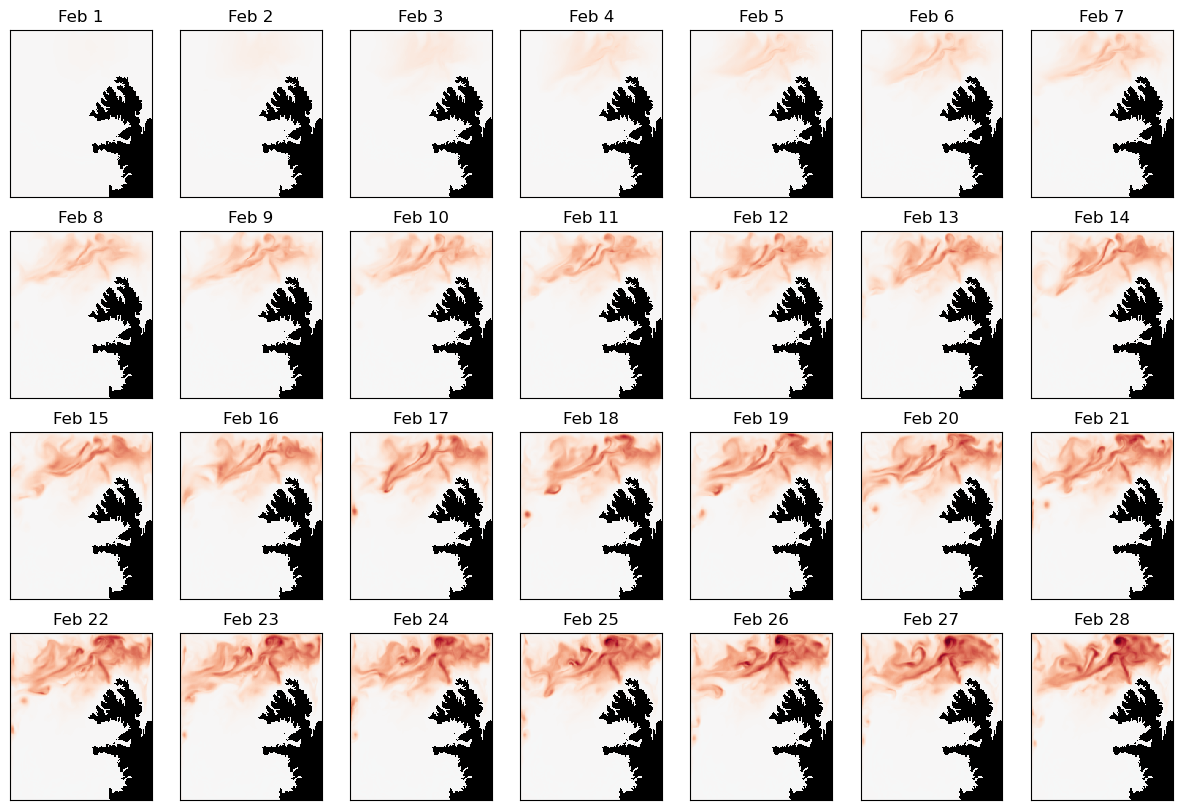

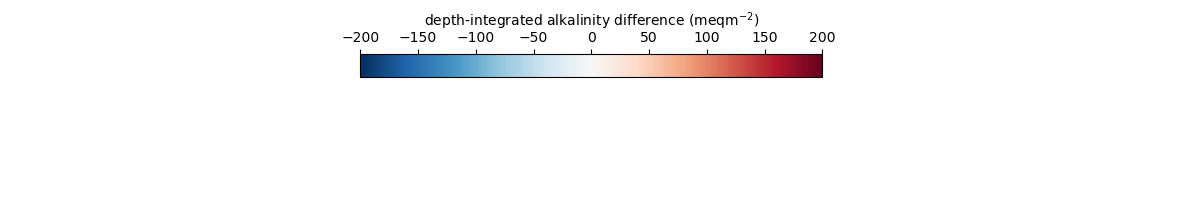

In [24]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

grid_ds=xr.open_dataset("input_data/iceland_child_grid.nc")

# Note that as we asked for daily averages in `cstar_output.opt`, the timestamp in the filename
# reflects the end of the first averaging period, when the file was first created - one day into the run:
data_ds=xr.open_dataset("output/iceland_child_cstar.20120202000000.nc")

depth_integrated_dAlk_feb = (data_ds["hALK"]-data_ds["hALK_ALT_CO2"]).sum("s_rho")

# Set up figure
fig,ax=plt.subplots(4,7)
fig.set_size_inches(15,10)

# Diverging colormap with black on land
cmap = plt.get_cmap("RdBu_r")
cmap.set_bad("k")

# Add panels for different days of output
for i in range(28):
    a = ax.reshape(-1)[i]
    p=depth_integrated_dAlk_feb.isel(time=i).where(grid_ds.mask_rho).plot(
        ax=a,add_colorbar=False,vmin=-200,vmax=200,cmap=cmap
    )
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlabel("")
    a.set_ylabel("")
    a.set_title(f"Feb {i+1}")

# Add a shared colorbar
fig2,ax2=plt.subplots()
cb=fig2.colorbar(p,ax=ax2,orientation="horizontal",location="top",label=r"depth-integrated alkalinity difference (meqm$^{-2}$)")
fig2.set_size_inches(15,2)
ax2.set_axis_off()




/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_62130/41077619.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data_ds=xr.open_dataset("output/iceland_child_cstar.20120202000000.nc")
/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_62130/41077619.py:26: UserWarning: Adding colorbar to a different Figure <Figure size 1500x1000 with 28 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  cb=fig2.colorbar

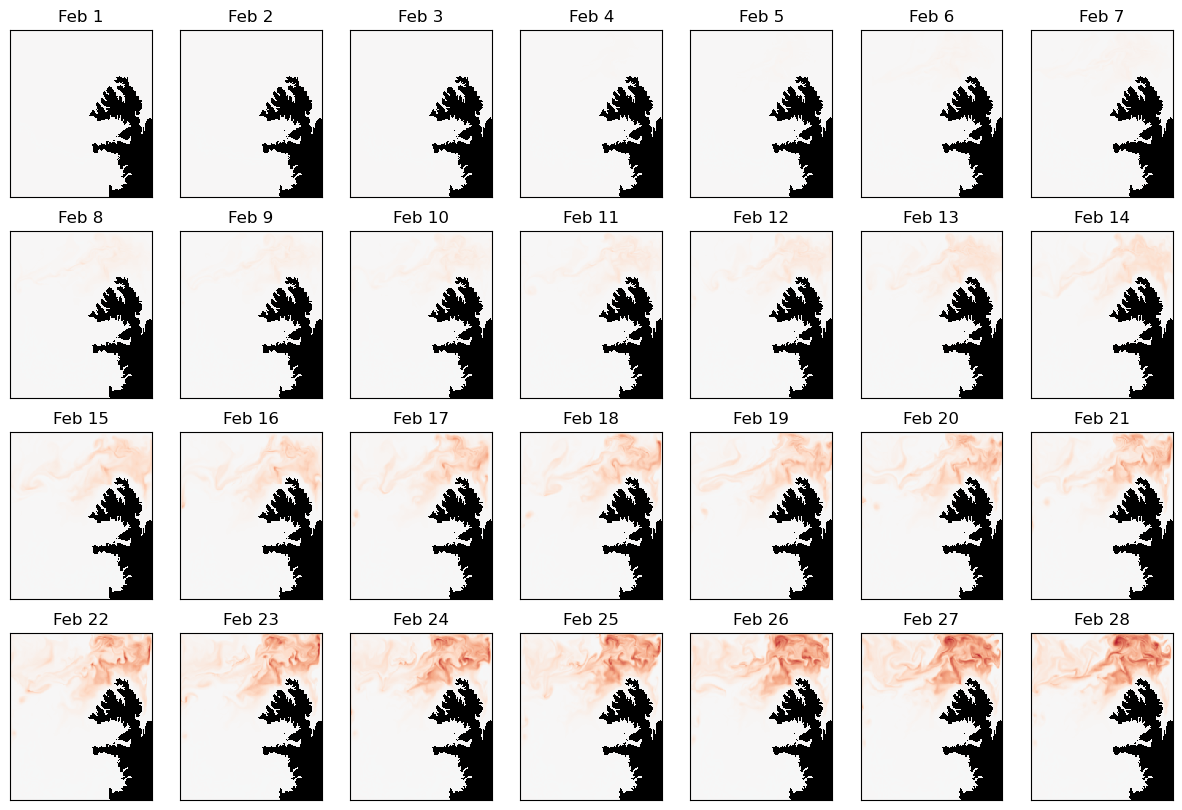

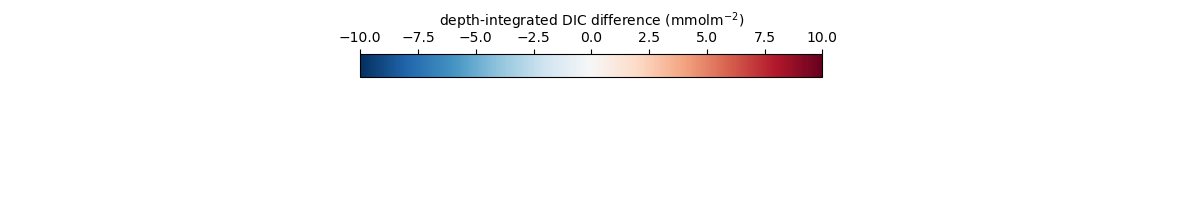

In [26]:
grid_ds=xr.open_dataset("input_data/iceland_child_grid.nc")
data_ds=xr.open_dataset("output/iceland_child_cstar.20120202000000.nc")

dint_dic_feb = (data_ds["hDIC"]-data_ds["hDIC_ALT_CO2"]).sum("s_rho")

# Set up figure
fig,ax=plt.subplots(4,7)
fig.set_size_inches(15,10)

# Diverging colormap with black on land
cmap = plt.get_cmap("RdBu_r")
cmap.set_bad("k")

# Add panels for different days of output
for i in range(28):
    a = ax.reshape(-1)[i]
    p=dint_dic_feb.isel(time=i).where(grid_ds.mask_rho).plot(ax=a,add_colorbar=False,vmin=-10,vmax=10,cmap=cmap)
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlabel("")
    a.set_ylabel("")
    a.set_title(f"Feb {i+1}")

# Add a shared colorbar
fig2,ax2=plt.subplots()
cb=fig2.colorbar(p,ax=ax2,orientation="horizontal",location="top",label=r"depth-integrated DIC difference (mmolm$^{-2}$)")
fig2.set_size_inches(15,2)
ax2.set_axis_off()


It is clear from the outputs that the additional alkalinity we injected into the domain is rapidly carried northwest and reaches the boundaries of the simulation, beyond which it can no longer be tracked in this run. Fortunately, we can "zoom out", re-running the parent simulation with the boundary fluxes from the child simulation, in order to see how the changes propagate beyond this domain. We will cover this in the next tutorial.

## Summary
In this tutorial, we:
- post-processed outputs from a previous simulation to create boundary and initial conditions
- generated surface, river, and tidal forcing data
- defined an alkalinity perturbation
- pre-processed this input data
- configured and compiled ROMS
- ran for one model month
- post-processed output data
- looked at CDR-specific outputs and visualized the impact of our alkalinity intervention

... for the child domain of a two-domain nested regional ocean simulation, continuing the work of our previous tutorial step. As part of this process, we configured ROMS' upscaling module to capture tracer fluxes at the boundaries of the domain, to be used as forcing in a second run of the parent simulation.

In the next tutorial, we will prepare and run this parent simulation to model the effects of the alkalinity perturbation after leaving our child domain.